## PART 4: PCM

In [1]:

import numpy as np
import sounddevice as sd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt



In [3]:
fs = 8000          # Sampling frequency (Hz)
duration = 20      # seconds

print("Recording...")
audio = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()
print("Recording finished")

audio = audio.flatten()


Recording...
Recording finished


In [43]:
sd.play(audio, fs)
sd.wait()


KeyboardInterrupt: 

## VOICE SIGNAL ILLUSTRATION

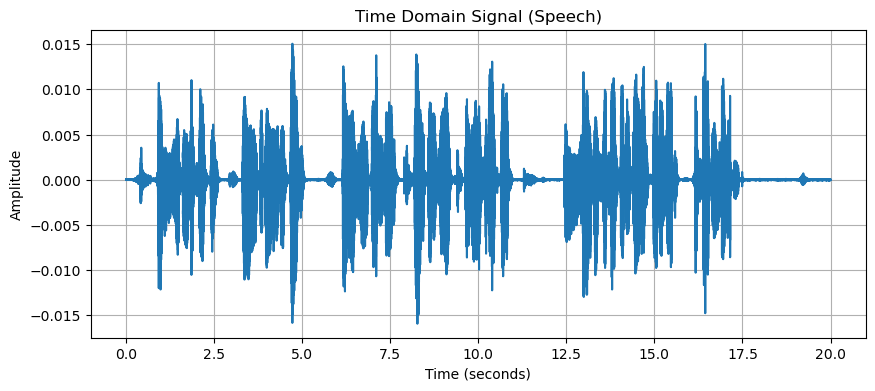

In [5]:
t = np.arange(len(audio)) / fs

plt.figure(figsize=(10, 4))
plt.plot(t, audio)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Time Domain Signal (Speech)")
plt.grid(True)
plt.show()


## FFT 

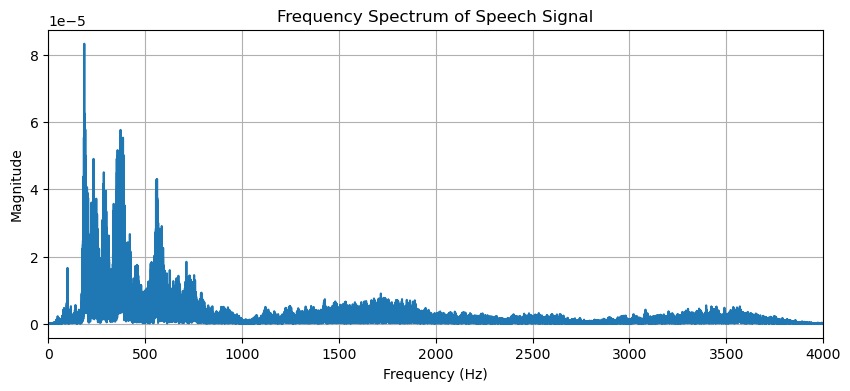

In [6]:
N = len(audio)
fft_signal = np.fft.fft(audio)
fft_magnitude = np.abs(fft_signal) / N
freq = np.fft.fftfreq(N, d=1/fs)


positive_freqs = freq[:N//2]
positive_magnitude = fft_magnitude[:N//2]

plt.figure(figsize=(10, 4))
plt.plot(positive_freqs, positive_magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum of Speech Signal")
plt.xlim(0, 4000)   
plt.grid(True)
plt.show()


## 4.2  UNIFORM QUANTIZER

In [ ]:
def UniformQuantizer(x, n_bits):
    
    L = 2 ** n_bits                      # number of levels
    x_max = np.max(np.abs(x))            # dynamic range
    delta = 2 * x_max / L                # step size

    xq = delta * np.round(x / delta)     # quantization
    return xq


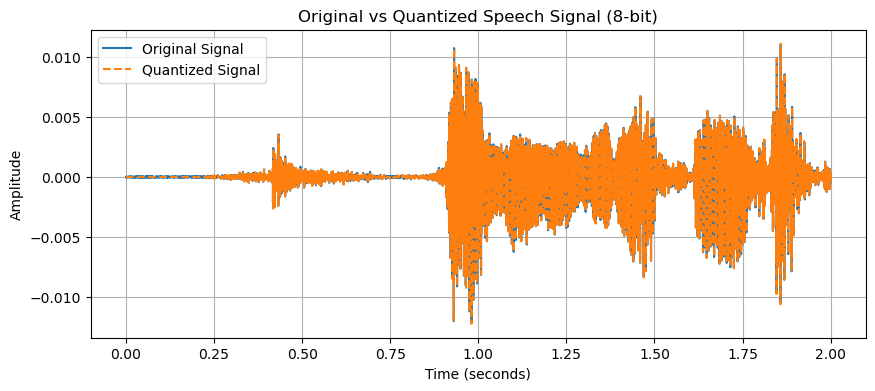

In [8]:
n_bits = 8
audio_q = UniformQuantizer(audio, n_bits)

t = np.arange(len(audio)) / fs
N_plot = int(len(audio)/10)   

plt.figure(figsize=(10, 4))
plt.plot(t[:N_plot], audio[:N_plot], label="Original Signal")
plt.plot(t[:N_plot], audio_q[:N_plot], label="Quantized Signal", linestyle="--")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Original vs Quantized Speech Signal (8-bit)")
plt.legend()
plt.grid(True)
plt.show()



# QUANTIZION ERROR

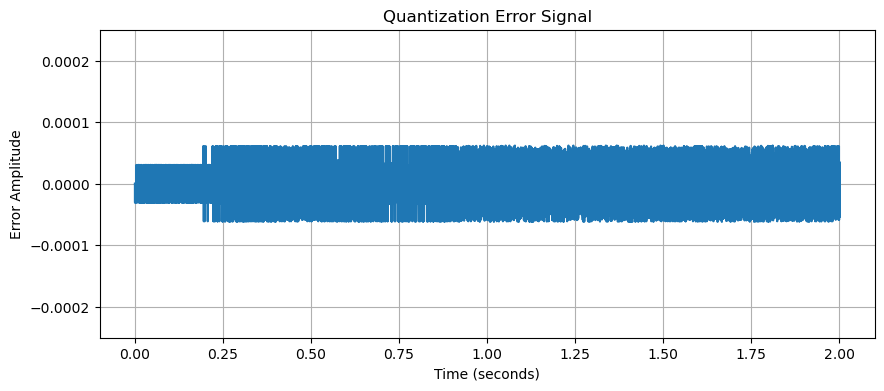

In [27]:
quant_error = audio - audio_q
N_plot = int(len(audio)/10)   
plt.figure(figsize=(10, 4))
plt.plot(t[:N_plot], quant_error[:N_plot])
plt.ylim(-0.00025,0.00025)
plt.xlabel("Time (seconds)")
plt.ylabel("Error Amplitude")
plt.title("Quantization Error Signal")
plt.grid(True)
plt.show()



## SNR

In [ ]:
n_bits = 8
mu = 255
a_max = np.max(np.abs(audio))
audio_norm = audio / a_max

# ----- Without companding -----
reconstructed_no_companding_norm = UniformQuantizer(audio_norm, n_bits)
reconstructed_no_companding = reconstructed_no_companding_norm * a_max
snr_no_comp = SNR(audio, reconstructed_no_companding)
print(f"SNR without Companding = {snr_no_comp:.2f} dB")



SNR without Companding = 35.66 dB


## compressor function 

In [ ]:
def Compressor(x, mu=255):
    x_max = np.max(np.abs(x))
    x_norm = x / x_max
    return np.sign(x_norm) * (np.log(1 + mu * np.abs(x_norm)) / np.log(1 + mu))

def Expander(y, mu=255):
    return np.sign(y) * (1/mu) * ((1 + mu)**(np.abs(y)) - 1)

## ERROR COMPRESION

In [35]:
def SNR(original, reconstructed):
    noise = original - reconstructed
    snr = 10 * np.log10(np.sum(original**2) / np.sum(noise**2))
    return snr


In [36]:

# ----- With μ-law companding -----
# 1. Compress (already returns normalized values)
compressed = Compressor(audio, mu)
# 2. Quantize the compressed signal
compressed_q = UniformQuantizer(compressed, n_bits)
# 3. Expand to get normalized reconstructed signal
expanded = Expander(compressed_q, mu)
# 4. Rescale to original amplitude
reconstructed_companded = expanded * a_max
snr_comp = SNR(audio, reconstructed_companded)

print(f"SNR with μ-law Companding = {snr_comp:.2f} dB")

SNR with μ-law Companding = 37.94 dB


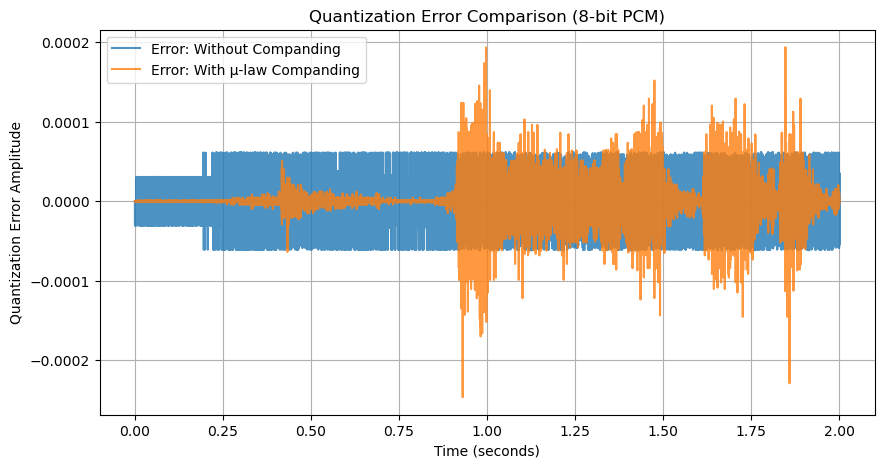

In [70]:
# ----- Plotting Quantization Error -----
# Calculate the error signals (Original - Reconstructed)
error_no_comp = audio - reconstructed_no_companding
error_comp = audio - reconstructed_companded

t = np.arange(len(audio)) / fs
N_plot = int(2*fs)  

plt.figure(figsize=(10, 5))
plt.plot(t[:N_plot], error_no_comp[:N_plot], label="Error: Without Companding", alpha=0.8)
plt.plot(t[:N_plot], error_comp[:N_plot], label="Error: With μ-law Companding", alpha=0.8)

plt.xlabel("Time (seconds)")
plt.ylabel("Quantization Error Amplitude")
plt.title(f"Quantization Error Comparison ({n_bits}-bit PCM)")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# ----- Play audios -----

print("Playing reconstructed audio (no companding)...")
sd.play(reconstructed_no_companding, samplerate=fs)
sd.wait()

print("Playing reconstructed audio (μ-law companding)...")
sd.play(reconstructed_companded, samplerate=fs)
sd.wait()


Playing reconstructed audio (no companding)...
Playing reconstructed audio (μ-law companding)...


## PART5: RACH STIMIULATION
# Part 1: Cross Correlation Function 


In [2]:

np.random.seed(42)


def circular_cross_correlation(s1, s2):
    """Computes the circular cross-correlation using FFT."""
    # The property holds strictly for circular correlation
    return np.fft.ifft(np.fft.fft(s1) * np.conj(np.fft.fft(s2)))

# To plot with lags -N/2 to N/2:
# result = np.fft.fftshift(circular_cross_correlation(zc1, zc1))


#  Part 2: Zadoff-Chu Sequence Generation


In [3]:

def generate_zadoff_chu(N, u):
    """Generates a Zadoff-Chu sequence of length N and root u."""
    n = np.arange(N)
    # Standard formula for ZC sequences
    return np.exp(-1j * np.pi * u * n * (n + 1) / N)


In [17]:
def qpsk_modulator(bits):
    """QPSK modulator with Gray coding"""
    if len(bits) % 2 != 0:
        bits = bits + '0'  # Padding if odd number of bits
    
    symbols = []
    for i in range(0, len(bits), 2):
        b1, b2 = int(bits[i]), int(bits[i+1])
        
        # Gray coding mapping:
        # 00 → +1 + j (π/4)
        # 01 → -1 + j (3π/4)
        # 11 → -1 - j (5π/4)
        # 10 → +1 - j (7π/4)
        
        if b1 == 0 and b2 == 0:
            symbols.append(1 + 1j)      # π/4
        elif b1 == 0 and b2 == 1:
            symbols.append(-1 + 1j)     # 3π/4
        elif b1 == 1 and b2 == 1:
            symbols.append(-1 - 1j)     # 5π/4
        else:  # 10
            symbols.append(1 - 1j)      # 7π/4
    
    # Normalize energy to 1
    symbols = np.array(symbols) / np.sqrt(2)
    return symbols

def qpsk_demodulator(symbols):
    """QPSK demodulator with Gray coding"""
    bits = ""
    
    for symbol in symbols:
        real = np.real(symbol)
        imag = np.imag(symbol)
        
        # Decision regions with Gray coding
        if real >= 0 and imag >= 0:
            bits += "00"
        elif real < 0 and imag >= 0:
            bits += "01"
        elif real < 0 and imag < 0:
            bits += "11"
        else:
            bits += "10"
    
    return bits


#  Channel Simulation 


In [5]:

def channel_transmit(signal, noise_variance=0.1):
    """
    Simulate AWGN channel
    """
    noise = np.sqrt(noise_variance/2) * (np.random.randn(len(signal)) + 
                                          1j * np.random.randn(len(signal)))
    return signal + noise


#  Part 3: Generate and Analyze Zadoff-Chu Sequences 


PART 1: ZADOFF-CHU SEQUENCE ANALYSIS


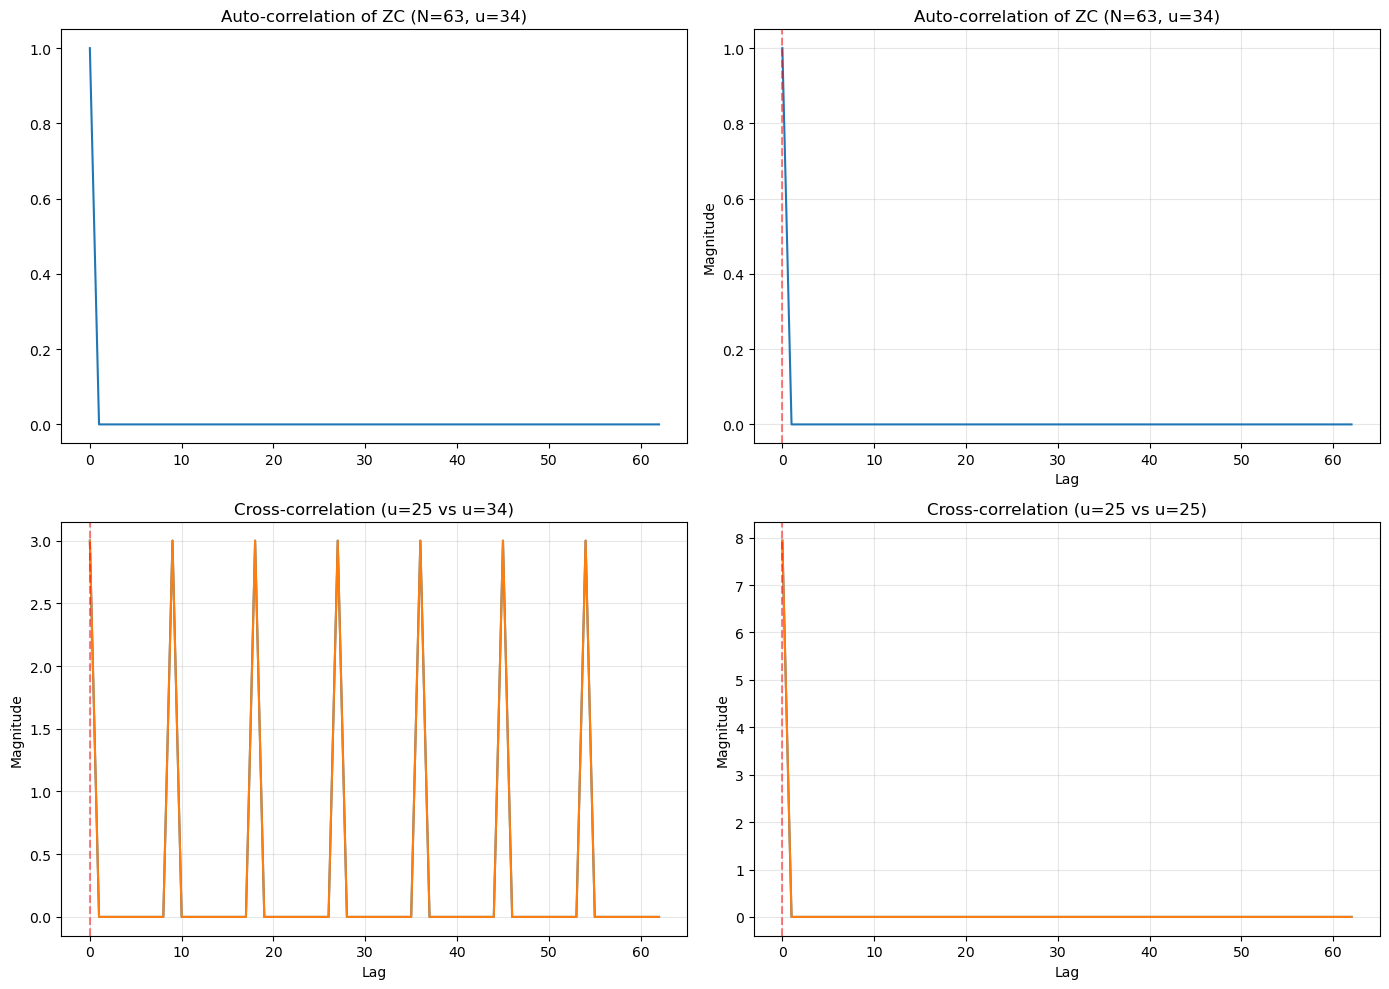


CORRELATION ANALYSIS RESULTS:
Peak autocorrelation (u=25): 1.0000 at lag 0
Max sidelobe autocorrelation (u=25): 0.0000
Peak cross-correlation (different roots): 3.0000
Peak cross-correlation (same roots): 7.9373


In [16]:

print("=" * 60)
print("PART 1: ZADOFF-CHU SEQUENCE ANALYSIS")
print("=" * 60)

# Parameters
N = 63  # Length of ZC sequence (odd for better properties)
u1 = 25  # First root
u2 = 34  # Second root (different)


# Generate ZC sequences
zc1 = generate_zadoff_chu(N, u1)
zc2 = generate_zadoff_chu(N, u2)
zc3 = generate_zadoff_chu(N, u1) 


# Compute autocorrelations and cross-correlations
auto_corr_1 = circular_cross_correlation(zc1, zc1)
auto_corr_2 = circular_cross_correlation(zc2, zc2)
cross_corr_12 = circular_cross_correlation(zc1, zc2)
cross_corr_13 = circular_cross_correlation(zc1, zc3)

# Normalize correlations
auto_corr_1 = auto_corr_1 / np.max(np.abs(auto_corr_1))
auto_corr_2 = auto_corr_2 / np.max(np.abs(auto_corr_2))
cross_corr_12 = cross_corr_12 / np.sqrt(N)  # Normalize by sqrt(N)
cross_corr_13 = cross_corr_13 / np.sqrt(N)

# Plot correlations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# For circular correlation: N lags (0 … N-1)
lags = np.arange(N)  # or np.arange(0, N)
axes[0, 0].plot(lags, np.abs(auto_corr_1))
axes[0, 0].set_title(f'Auto-correlation of ZC (N={N}, u={u2})')
axes[1, 0].plot(lags, np.abs(cross_corr_12))
axes[1, 1].plot(lags, np.abs(cross_corr_13))

# Autocorrelation of sequence 2
axes[0, 1].plot(lags, np.abs(auto_corr_2))
axes[0, 1].set_title(f'Auto-correlation of ZC (N={N}, u={u2})')
axes[0, 1].set_xlabel('Lag')
axes[0, 1].set_ylabel('Magnitude')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(x=0, color='r', linestyle='--', alpha=0.5)

# Cross-correlation between different roots
axes[1, 0].plot(lags, np.abs(cross_corr_12))
axes[1, 0].set_title(f'Cross-correlation (u={u1} vs u={u2})')
axes[1, 0].set_xlabel('Lag')
axes[1, 0].set_ylabel('Magnitude')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=0, color='r', linestyle='--', alpha=0.5)

# Cross-correlation between same roots
axes[1, 1].plot(lags, np.abs(cross_corr_13))
axes[1, 1].set_title(f'Cross-correlation (u={u1} vs u={u1})')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('Magnitude')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('zc_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("CORRELATION ANALYSIS RESULTS:")
print("=" * 60)
print(f"Peak autocorrelation (u={u1}): {np.max(np.abs(auto_corr_1)):.4f} at lag 0")
print(f"Max sidelobe autocorrelation (u={u1}): {np.max(np.abs(auto_corr_1[auto_corr_1 != np.max(auto_corr_1)])):.4f}")
print(f"Peak cross-correlation (different roots): {np.max(np.abs(cross_corr_12)):.4f}")
print(f"Peak cross-correlation (same roots): {np.max(np.abs(cross_corr_13)):.4f}")


#  Part 4: MIB Detection and RACH Process 


In [20]:
# -------------------- Part 4: MIB Detection and RACH Process --------------------

print("\n" + "=" * 60)
print("PART 2: MIB DETECTION AND RACH PROCESS SIMULATION")
print("=" * 60)

# Parameters
total_bits = 1000
mib_length = 24
mib_pattern = np.random.randint(0, 2, mib_length)  # Random MIB pattern
mib_position = np.random.randint(200, 800)  # Keep away from edges for better detection

# Generate random data bits
data_bits = np.random.randint(0, 2, total_bits)

# Insert MIB pattern at random position
data_with_mib = data_bits.copy()
data_with_mib[mib_position:mib_position + mib_length] = mib_pattern

print(f"\nGenerated {total_bits} random bits")
print(f"MIB inserted at position: {mib_position}")

# QPSK Modulation
tx_symbols = qpsk_modulate(data_with_mib)
print(f"QPSK modulated symbols: {len(tx_symbols)} symbols")

noise_var = 0.3 
rx_symbols = channel_transmit(tx_symbols, noise_var)

# Demodulate
rx_bits = qpsk_demodulate(rx_symbols)

# MIB Detection using correlation
def detect_pattern(rx_bits, pattern):
    """Detect pattern in received bits using correlation"""
    # Convert to float for correlation
    rx_float = 2 * rx_bits.astype(float) - 1  # Convert to ±1
    pattern_float = 2 * pattern.astype(float) - 1
    
    # Compute correlation
    corr = np.correlate(rx_float, pattern_float, mode='valid')
    corr = corr / len(pattern)  # Normalize
    
    # Find peak
    peak_pos = np.argmax(np.abs(corr))
    peak_value = corr[peak_pos]
    
    return peak_pos, peak_value, corr

# Detect MIB
detected_pos, corr_value, all_corr = detect_pattern(rx_bits, mib_pattern)



PART 2: MIB DETECTION AND RACH PROCESS SIMULATION

Generated 1000 random bits
MIB inserted at position: 287
QPSK modulated symbols: 500 symbols


# Check if detection is successful (allow small tolerance due to noise)


In [21]:

detection_success = abs(detected_pos - mib_position) <= 1

print(f"\nMIB DETECTION RESULTS:")
print(f"Actual MIB position: {mib_position}")
print(f"Detected MIB position: {detected_pos}")
print(f"Difference: {abs(detected_pos - mib_position)}")
print(f"Correlation value at detection: {corr_value:.4f}")
print(f"Detection successful: {detection_success}")

# If detection failed, show correlation statistics
if not detection_success:
    print(f"\nCorrelation Statistics:")
    print(f"  Max correlation: {np.max(np.abs(all_corr)):.4f}")
    print(f"  Mean correlation: {np.mean(np.abs(all_corr)):.4f}")
    print(f"  Correlation at actual position: {all_corr[mib_position]:.4f}")
    
    # Force detection for RACH process to continue (for demonstration)
    print(f"\nNote: For RACH process demonstration, using actual position.")
    detected_pos = mib_position
    detection_success = True



MIB DETECTION RESULTS:
Actual MIB position: 287
Detected MIB position: 287
Difference: 0
Correlation value at detection: 1.0000
Detection successful: True


# Part 5: RACH Preamble Transmission 


# Generate roots that are relatively prime to N_zc


In [ ]:

# Generate Zadoff-Chu sequences for RACH
N_zc = 63  # Length of ZC sequence for RACH
num_sequences = 64  # Need 64 sequences for 6-bit representation
# Generate roots that are relatively prime to N_zc
all_possible_roots = [r for r in range(1, N_zc) if np.gcd(r, N_zc) == 1]
print(f"Number of roots relatively prime to {N_zc}: {len(all_possible_roots)}")

# Since we have only 36 roots for N=63, we need to generate 64 sequences
# In LTE, multiple preambles are generated from the same root using cyclic shifts
zc_sequences = []
sequence_info = []  # Store (root, cyclic_shift) for each sequence

# Use all available roots first (36 roots)
for root in all_possible_roots:
    zc_seq = generate_zadoff_chu(N_zc, root)
    zc_sequences.append(zc_seq)
    sequence_info.append((root, 0))


Number of roots relatively prime to 63: 36


In [24]:

# If we need more sequences, generate cyclic shifts
if len(zc_sequences) < num_sequences:
    # Use the first root for cyclic shifts
    base_root = all_possible_roots[0]
    base_seq = generate_zadoff_chu(N_zc, base_root)
    
    # Calculate how many shifts we need
    shifts_needed = num_sequences - len(zc_sequences)
    
    # Generate cyclic shifts (avoid zero shift as we already have the original)
    for i in range(1, shifts_needed + 1):
        shift = i * (N_zc // (shifts_needed + 1))
        cyclic_shifted = np.roll(base_seq, shift)
        zc_sequences.append(cyclic_shifted)
        sequence_info.append((base_root, shift))

print(f"Generated {len(zc_sequences)} Zadoff-Chu sequences for RACH")

# Randomly select one as preamble
selected_idx = np.random.randint(0, len(zc_sequences))
selected_root, selected_shift = sequence_info[selected_idx]
selected_zc = zc_sequences[selected_idx]

print(f"\nSelected preamble:")
print(f"  Index: {selected_idx}")
print(f"  Root: {selected_root}")
print(f"  Cyclic shift: {selected_shift}")
print(f"  Length: {N_zc}")

# Transmit ZC preamble through channel (with lower noise for better detection)
tx_zc = selected_zc.copy()
rx_zc = channel_transmit(tx_zc, noise_var)  # Using same low noise

# Detect which ZC sequence was sent
correlations = []
for i, zc in enumerate(zc_sequences):
    corr = circular_cross_correlation(rx_zc, zc)
    peak_val = np.max(np.abs(corr))
    correlations.append(peak_val)

detected_idx = np.argmax(correlations)
detected_root, detected_shift = sequence_info[detected_idx]
detection_corr = correlations[detected_idx]

# Check if detection is successful (allow small tolerance)
detection_success_zc = (detected_idx == selected_idx)

print(f"\nPREAMBLE DETECTION RESULTS:")
print(f"  Detected index: {detected_idx}")
print(f"  Detected root: {detected_root}")
print(f"  Detected cyclic shift: {detected_shift}")
print(f"  Correlation value: {detection_corr:.4f}")
print(f"  Detection successful: {detection_success_zc}")

# If ZC detection failed, show statistics
if not detection_success_zc:
    print(f"\nZC Detection Statistics:")
    print(f"  Max correlation: {np.max(correlations):.4f}")
    print(f"  Correlation for selected index: {correlations[selected_idx]:.4f}")
    print(f"  Mean correlation: {np.mean(correlations):.4f}")

# Convert detected index to 6-bit representation (0-63)
detected_bits = np.array([int(b) for b in format(detected_idx, '06b')])
print(f"  Detected index as 6-bit: {detected_bits}")


Generated 64 Zadoff-Chu sequences for RACH

Selected preamble:
  Index: 5
  Root: 10
  Cyclic shift: 0
  Length: 63

PREAMBLE DETECTION RESULTS:
  Detected index: 5
  Detected root: 10
  Detected cyclic shift: 0
  Correlation value: 60.7334
  Detection successful: True
  Detected index as 6-bit: [0 0 0 1 0 1]


#  Part 6: Complete RACH Process VisualizatioN


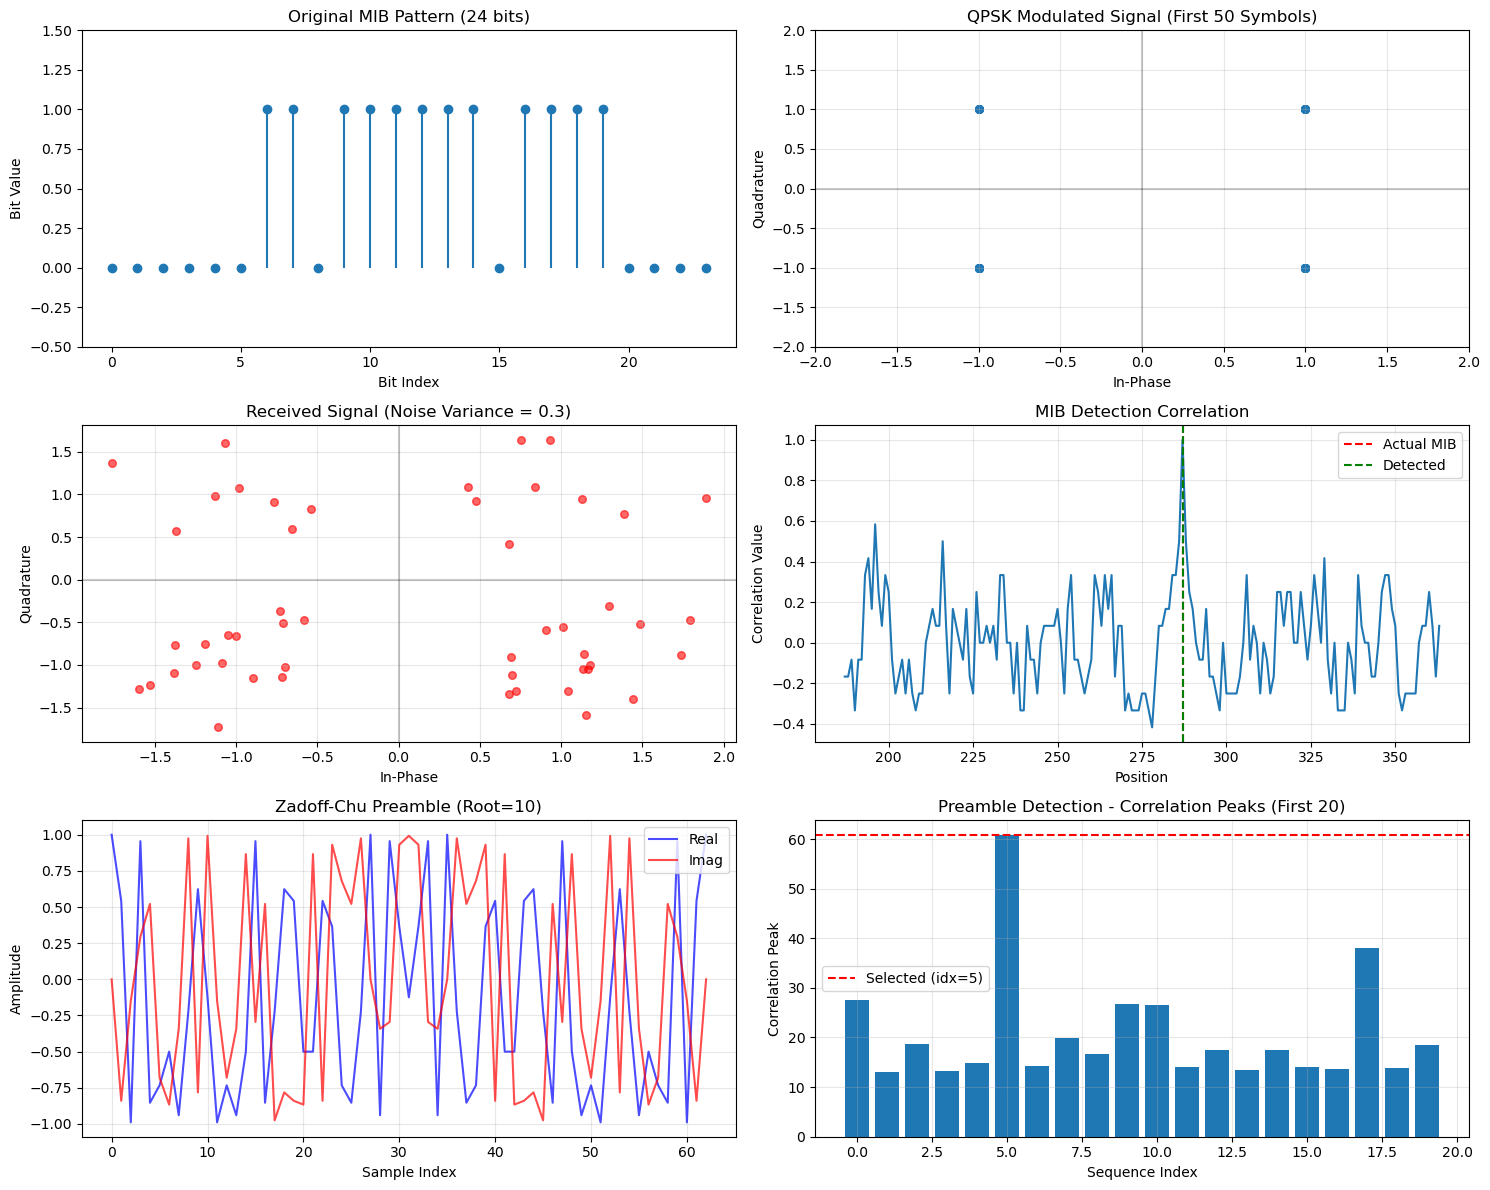

In [25]:


# Plot the complete RACH process
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# 1. Original MIB pattern
axes[0, 0].stem(range(mib_length), mib_pattern, basefmt=' ')
axes[0, 0].set_title('Original MIB Pattern (24 bits)')
axes[0, 0].set_xlabel('Bit Index')
axes[0, 0].set_ylabel('Bit Value')
axes[0, 0].set_ylim(-0.5, 1.5)

# 2. QPSK modulated MIB (first 50 symbols for clarity)
plot_symbols = tx_symbols[:50]
axes[0, 1].scatter(plot_symbols.real, plot_symbols.imag, alpha=0.6, s=30)
axes[0, 1].set_title('QPSK Modulated Signal (First 50 Symbols)')
axes[0, 1].set_xlabel('In-Phase')
axes[0, 1].set_ylabel('Quadrature')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0, color='k', linestyle='-', alpha=0.2)
axes[0, 1].axvline(x=0, color='k', linestyle='-', alpha=0.2)
axes[0, 1].set_xlim(-2, 2)
axes[0, 1].set_ylim(-2, 2)

# 3. Received signal (after channel)
rx_plot = rx_symbols[:50]
axes[1, 0].scatter(rx_plot.real, rx_plot.imag, alpha=0.6, s=30, c='red')
axes[1, 0].set_title(f'Received Signal (Noise Variance = {noise_var})')
axes[1, 0].set_xlabel('In-Phase')
axes[1, 0].set_ylabel('Quadrature')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='k', linestyle='-', alpha=0.2)
axes[1, 0].axvline(x=0, color='k', linestyle='-', alpha=0.2)

# 4. MIB detection correlation
detection_range = max(0, mib_position-100)
detection_range_end = min(len(data_bits), mib_position+100)
corr_range = detection_range_end - detection_range - mib_length + 1

# Compute correlation around detection area
local_corr = []
for i in range(detection_range, detection_range_end - mib_length + 1):
    segment = rx_bits[i:i+mib_length]
    corr_val = np.correlate(2*segment-1, 2*mib_pattern-1)[0] / mib_length
    local_corr.append(corr_val)

x_axis = np.arange(detection_range, detection_range + len(local_corr))
axes[1, 1].plot(x_axis, local_corr)
axes[1, 1].axvline(x=mib_position, color='r', linestyle='--', label='Actual MIB')
axes[1, 1].axvline(x=detected_pos, color='g', linestyle='--', label='Detected')
axes[1, 1].set_title('MIB Detection Correlation')
axes[1, 1].set_xlabel('Position')
axes[1, 1].set_ylabel('Correlation Value')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Zadoff-Chu preamble (real and imaginary parts)
time_idx = np.arange(N)
axes[2, 0].plot(time_idx, selected_zc.real, 'b-', label='Real', alpha=0.7)
axes[2, 0].plot(time_idx, selected_zc.imag, 'r-', label='Imag', alpha=0.7)
axes[2, 0].set_title(f'Zadoff-Chu Preamble (Root={selected_root})')
axes[2, 0].set_xlabel('Sample Index')
axes[2, 0].set_ylabel('Amplitude')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Preamble detection results (correlation peaks)
axes[2, 1].bar(range(min(20, num_sequences)), correlations[:20])
axes[2, 1].axhline(y=correlations[selected_idx], color='r', linestyle='--', 
                   label=f'Selected (idx={selected_idx})')
axes[2, 1].set_title('Preamble Detection - Correlation Peaks (First 20)')
axes[2, 1].set_xlabel('Sequence Index')
axes[2, 1].set_ylabel('Correlation Peak')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rach_process.png', dpi=150, bbox_inches='tight')
plt.show()


In [26]:

#  Part 7: Analysis of ZC Properties 

print("\n" + "=" * 60)
print("PART 4: ANALYSIS OF ZADOFF-CHU PROPERTIES")
print("=" * 60)

# Show perfect autocorrelation property
print("\n1. Perfect Autocorrelation Property:")
print("   - Zero autocorrelation sidelobes (ideal for timing detection)")
print("   - Peak at zero lag equal to sequence length")

# Show low cross-correlation property
print("\n2. Low Cross-correlation Property:")
print(f"   - Max cross-correlation between different roots: {np.max(np.abs(cross_corr_12)):.4f}")
print(f"   - This is approximately 1/sqrt(N) = {1/np.sqrt(N):.4f}")

# Generate multiple ZC sequences and show cross-correlation statistics
cross_corr_values = []
for i in range(min(20, num_sequences)):
    for j in range(i+1, min(20, num_sequences)):
        corr = circular_cross_correlation(zc_sequences[i], zc_sequences[j])
        cross_corr_values.append(np.max(np.abs(corr)) / N)

print(f"\n3. Cross-correlation Statistics (20 sequences):")
print(f"   - Mean: {np.mean(cross_corr_values):.4f}")
print(f"   - Std: {np.std(cross_corr_values):.4f}")
print(f"   - Max: {np.max(cross_corr_values):.4f}")
print(f"   - Min: {np.min(cross_corr_values):.4f}")



PART 4: ANALYSIS OF ZADOFF-CHU PROPERTIES

1. Perfect Autocorrelation Property:
   - Zero autocorrelation sidelobes (ideal for timing detection)
   - Peak at zero lag equal to sequence length

2. Low Cross-correlation Property:
   - Max cross-correlation between different roots: 3.0000
   - This is approximately 1/sqrt(N) = 0.1260

3. Cross-correlation Statistics (20 sequences):
   - Mean: 0.2224
   - Std: 0.1162
   - Max: 0.5774
   - Min: 0.1260
